# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

#### Import the necessary code libraries

In [90]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [150]:
import pandas as pd

TOP_BRL =['000001.SS', '399001.SZ', '603000.SS','000035.SZ','002261.SZ','000938.SZ','600547.SS','600756.SS','601899.SS','601988.SS']

# 读取CSV文件
df_portfolio = pd.read_csv('/Users/pu17/Documents/stock/FinRL/examples/df_portfolio.csv')
# 定义要过滤的股票代码列表
target_tics = ['000001.SS', '399001.SZ']

# 使用布尔索引过滤出指定股票代码的数据
df_portfolio = df_portfolio[df_portfolio['tic'].isin(target_tics)]
print(df_portfolio.head())

df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2018-01-01") & (df_portfolio["date"] < "2024-02-01")]
df_portfolio_2023 = df_portfolio[(df_portfolio["date"] >= "2024-02-01") & (df_portfolio["date"] < "2024-06-31")]
df_portfolio_2024 = df_portfolio[(df_portfolio["date"] >= "2024-07-01") & (df_portfolio["date"] <= "2024-10-23")]

# 定义特征列表
features = [
'volume', 'day', 'macd','boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma','close_60_sma',
    'up_down_ratio', 'market_breadth',
    'net_sm_amount', 
     'net_lg_amount','net_elg_amount',
    'net_sm_pct', 'net_md_pct', 'net_lg_pct', 'net_elg_pct',
    'spring_festival_pre_holiday', 'spring_festival_post_holiday',
    'labor_day_pre_holiday', 'labor_day_post_holiday',
    'national_day_pre_holiday', 'national_day_post_holiday', 'dayofmonth',
    'dayofyear'
]


         date      open      high       low     close    volume        tic  \
0  2016-01-04  0.950418  0.948281  0.892473  0.887195  0.140388  000001.SS   
1  2016-01-05  0.859064  0.891859  0.863731  0.884895  0.203198  000001.SS   
2  2016-01-06  0.884471  0.901194  0.890629  0.904847  0.181880  000001.SS   
3  2016-01-07  0.889433  0.886906  0.843768  0.841101  0.053750  000001.SS   
4  2016-01-08  0.858519  0.867021  0.827790  0.857630  0.218043  000001.SS   

    day      macd   boll_ub  ...  net_md_vol  net_md_amount  net_lg_vol  \
0  0.00  0.000000  0.879068  ...    0.464375       0.535060   -0.416632   
1  0.25 -0.001391  0.879068  ...    0.202673       0.202540   -0.314192   
2  0.50  0.014898  0.903628  ...   -0.209774      -0.094199   -0.053994   
3  0.75 -0.040068  0.922993  ...    0.105300       0.104326   -0.164357   
4  1.00 -0.051372  0.915356  ...   -0.009979       0.075132   -0.198851   

   net_lg_amount  net_elg_vol  net_elg_amount  net_sm_pct  net_md_pct  \
0      

### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [151]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=10,
        features=features,
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [152]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.001,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 10,
    "initial_features":len(features)
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [153]:
environment_2023 = PortfolioOptimizationEnv(
    df_portfolio_2023,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=10,
    features=features,
    normalize_df=None
)

environment_2024 = PortfolioOptimizationEnv(
    df_portfolio_2024,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=10,
    features=features,
    normalize_df=None
)

### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [154]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2023": {},
    "2024": {}
}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=10, initial_features=len(features),device=device)
policy.load_state_dict(torch.load("/Users/pu17/Documents/stock/FinRL/examples/policy_EIIE_27_2.pt"))

# 2021
DRLAgent.DRL_validation(model, environment_2023, policy=policy)
EIIE_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
DRLAgent.DRL_validation(model, environment_2024, policy=policy)
EIIE_results["2024"]["value"] = environment_2024._asset_memory["final"]
# 打印环境中保存的动作
print("Actions memory:",pd.DataFrame(environment_2024._actions_memory))

Initial portfolio value:100000
Final portfolio value: 99966.35072757829
Final accumulative portfolio value: 0.9996635072757829
Maximum DrawDown: -0.00033649272421709675
Sharpe ratio: -19.808543692652403
Initial portfolio value:100000
Final portfolio value: 99978.42319165975
Final accumulative portfolio value: 0.9997842319165975
Maximum DrawDown: -0.0002157680834025122
Sharpe ratio: -23.153304774432737
Actions memory:            0         1
0   1.000000  0.000000
1   0.999952  0.000048
2   0.999962  0.000038
3   0.999960  0.000040
4   0.999970  0.000030
..       ...       ...
60  0.999995  0.000005
61  0.999996  0.000004
62  0.999995  0.000005
63  0.999993  0.000007
64  0.999991  0.000009

[65 rows x 2 columns]


In [155]:
for i, action in enumerate(environment_2024._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0.]
Action at step 1: [9.9995184e-01 4.8214799e-05]
Action at step 2: [9.9996161e-01 3.8430226e-05]
Action at step 3: [9.9996006e-01 3.9925853e-05]
Action at step 4: [9.9996972e-01 3.0334795e-05]
Action at step 5: [9.9997032e-01 2.9689303e-05]
Action at step 6: [9.9997413e-01 2.5908168e-05]
Action at step 7: [9.9997544e-01 2.4505985e-05]
Action at step 8: [9.9997544e-01 2.4560804e-05]
Action at step 9: [9.9998343e-01 1.6587834e-05]
Action at step 10: [9.9998581e-01 1.4157461e-05]
Action at step 11: [9.9998879e-01 1.1205169e-05]
Action at step 12: [9.9998939e-01 1.0616124e-05]
Action at step 13: [9.9998832e-01 1.1675453e-05]
Action at step 14: [9.9998868e-01 1.1268931e-05]
Action at step 15: [9.9998701e-01 1.2951057e-05]
Action at step 16: [9.9998498e-01 1.5002626e-05]
Action at step 17: [9.9998367e-01 1.6377580e-05]
Action at step 18: [9.9997604e-01 2.3918856e-05]
Action at step 19: [9.9997449e-01 2.5557592e-05]
Action at step 20: [9.999685e-01 3.149999e-05]
Actio

### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [158]:
UBAH_results = {
    "train": {},
    # "2020": {},
    "2023": {},
    "2024": {}
}

PORTFOLIO_SIZE = 1

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# # 2020
# terminated = False
# environment_2020.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2020.step(action)
# UBAH_results["2020"]["value"] = environment_2020._asset_memory["final"]

# 2021
terminated = False
environment_2023.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2023.step(action)
UBAH_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
terminated = False
environment_2024.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2024.step(action)
UBAH_results["2024"]["value"] = environment_2024._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 6.918955980133717e-100
Final accumulative portfolio value: 6.918955980133717e-105
Maximum DrawDown: -1.0
Sharpe ratio: -32.19025465015218
Initial portfolio value:100000
Final portfolio value: 0.014586313545783727
Final accumulative portfolio value: 1.4586313545783727e-07
Maximum DrawDown: -0.9999998541368645
Sharpe ratio: -114.66266539128192
Initial portfolio value:100000
Final portfolio value: 0.029205957202894723
Final accumulative portfolio value: 2.920595720289472e-07
Maximum DrawDown: -0.9999997079404279
Sharpe ratio: -57.605453989641255


### Plot graphics

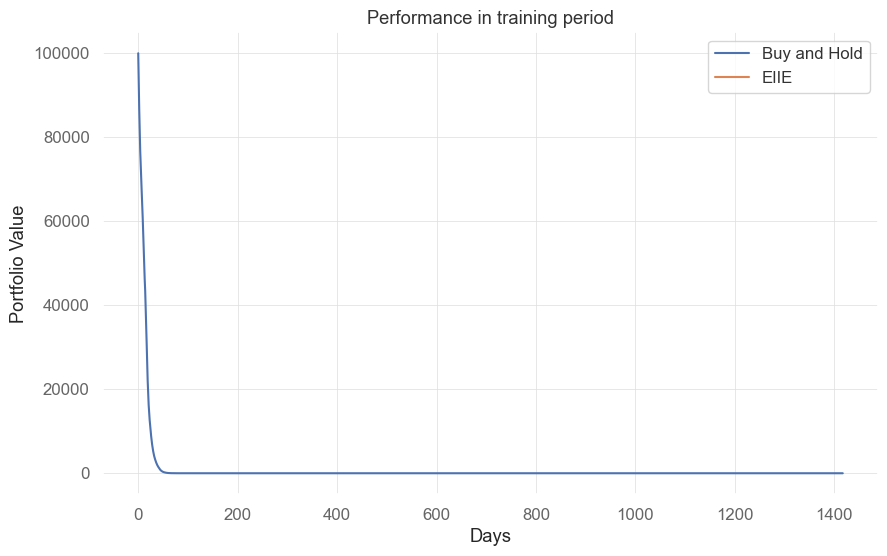

In [159]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

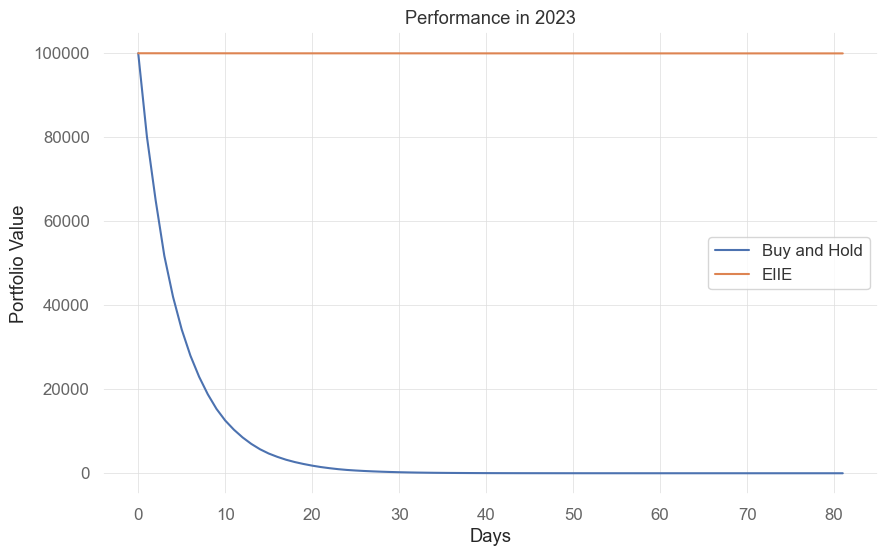

In [160]:
plt.plot(UBAH_results["2023"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2023"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2023")
plt.legend()

plt.show()

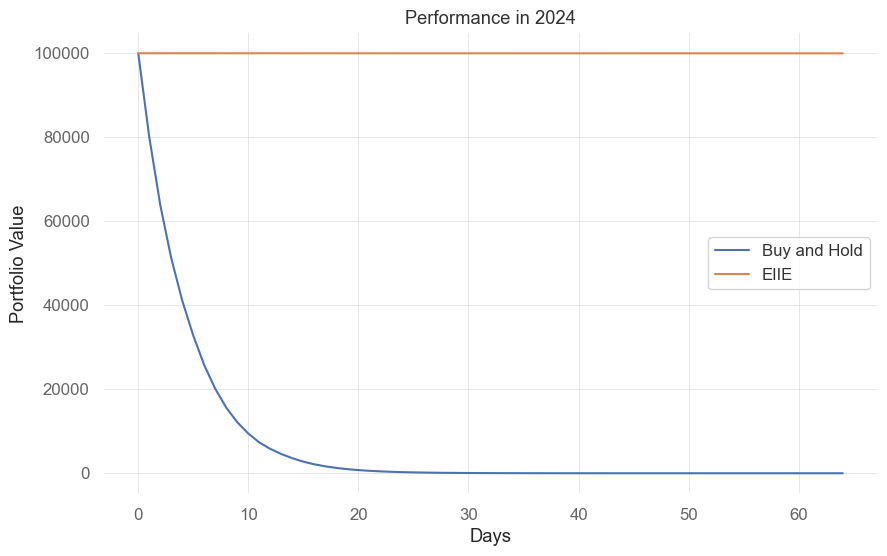

In [161]:
plt.plot(UBAH_results["2024"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2024"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2024")
plt.legend()

plt.show()

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.